# VAC-WTMetaD simulation using "data rich" CVs


## 1. Grab SRV from unbiased simulation folder

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import openmm as mm
import openmm.unit as unit
from openmm.app import Simulation, ForceField
from openmmtorch import TorchForce

from src.data import simulation_data
from src.util import torch_device, module_device

device = torch_device()
sd = simulation_data("data/unbiased")
net = sd.srv_net
print(f"{module_device(net) = }")

PyTorch version: 2.9.1+cu130
CUDA version (PyTorch): 13.0
CUDA available: True
CUDA device count: 1
Using device=device(type='cuda')
module_device(net) = device(type='cpu')


## 2. Simulation
* use the Gaussian centers themselves as the data (it is denser)
* compute the bias from the `Gaussians` object that corresponds to the snapshot when the Gaussian was deposited during the simulation.  These frames, separated by `p.tau_G` (120 fs) correspond to:
$$
\verb|biases[n]| = V_{n-1}(s_n)
$$

In [ ]:
from src.param import param_datarich_metad
from src.metad import SimulationCVS, metadynamics
from src.gaussians import load_gaussians
from src.util import create_system, state_data_reporter, hdf5_reporter
from tqdm.notebook import tqdm

p = param_datarich_metad()
metad = metadynamics(p.temperature, p.bias_factor, p.height, p.width)
scvs = SimulationCVS(p.pdb_file)
pdb = scvs.pdb()
forcefield = ForceField("amber99sb.xml", "tip3p.xml")

step_start = 52  #  June 18-23, 2026
num_steps = 100
do_simulation = True

if do_simulation:
    for step in range(step_start, num_steps):
        print(f"starting simulation {step}")

        # Case 1: Startiing simulation 0: 'start_positions' from pdf file
        # First Gaussian is why
        if step == 0:
            metad.add_gaussian(scvs.pdb_cvs(net))
            start_positions = pdb.positions
        else:
            # Case 2: Restarting simulation 'step' > 0: Temporarily load previous 'simulation_data' for 'start_positions
            if step == step_start:
                sd = simulation_data(p, subdir=(step - 1))

            # Case 2 and Case 3: Continuing current simulation: Previous 'simulation_data' is in memory.
            start_positions = sd.final_positions

            # metad.reset keeps track of current length of metad.gaussians
            # for:
            #     'current.npz' : full simulation (compressed) Gaussians
            #     'deposited.npz' : full set of Gaussians from current step
            metad.reset(load_gaussians(sd.working_dir / "current.npz"))

        sd = simulation_data(p, subdir=step)
        module = metad.force_module(net)
        torch.jit.script(module).save("data/force_module.pt")
        torch_force = TorchForce("data/force_module.pt")
        torch_force.addGlobalParameter("add_gaussian", False)
        torch_force.addGlobalParameter("height", 0.0)
        torch_force.addGlobalParameter("center1", 0.0)
        torch_force.addGlobalParameter("center2", 0.0)

        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        system = create_system(forcefield, pdb.topology)
        system.addForce(torch_force)
        # Proper way to keep track of biases, BUT, I'm going to
        # use the set of Gaussian centers from metad objects rather
        # than the usual (.h5 file) simulation frames for now.  It's
        # a denser set of data and the biases can be reconstructed from
        # the state of metad.
        # force_group_id = system.addForce(force)

        simulation = Simulation(pdb.topology, system, integrator)
        simulation.context.setPositions(start_positions)
        sdr = state_data_reporter(str(sd.files["outfile"]), p.report_interval)
        hdr = hdf5_reporter(str(sd.files["h5file"]), p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        simulation.step(p.steps_per_gaussian)

        for n in tqdm(range(p.num_gaussians - 1)):
            metad.add_gaussian(scvs.sim_cvs(net, simulation))
            simulation.context.setParameter("add_gaussian", True)
            simulation.context.setParameter("height", metad.heights[-1])
            simulation.context.setParameter("center1", metad.centers[-1][0])
            simulation.context.setParameter("center2", metad.centers[-1][1])
            simulation.step(1)
            simulation.context.setParameter("add_gaussian", False)
            simulation.step(p.steps_per_gaussian - 1)

        print(f"Saving simulation data at {sd.working_dir}")
        # sd.save_feature_data(recalculate=True, pdbfile=p.pdb_file)
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({"final_positions": r})

        # Save set of Gaussians deposited during current step
        metad.step_deposits.save_npz(sd.working_dir / "deposited.npz")

        # Save current set of Gaussians to be loaded on next step
        print(f"Compressing {len(metad)} kernels")
        metad.gaussians.compressed(dist_threshold=1.0).save_npz(
            sd.working_dir / "current.npz"
        )
        # h5 file must be closed before 'sd.save_feature_data'
        # TODO: move this to above sd.save_feature_data(recalculate=True, pdbfile=p.pdb_file) so that .h5 file is read-only
        for reporter in simulation.reporters:
            if hasattr(reporter, "close"):
                reporter.close()

starting simulation 52


  0%|          | 0/8332 [00:00<?, ?it/s]

# 3. Gather data and compute biases
$$
\textrm{frames: }\{s_k\},\quad\textrm{Gaussians: }\{G_k(s)\},\quad
\textrm{biases: }\{V_{k-1}(s_k)\}
$$
### A. Use `metad.centers` as data.  Reconstruct bias potential.
For reweighting the metadynamics data, you need the value of the bias potential at the frame configuration:
$$
\mathrm{e}^{\beta V_t(s_t)}
$$
where the state of the bias potential $V_t$ is at the moment the configuration encountered it.  That is, for metadynamics simulation, reconstruct
$$
V_{n-1}(s_n), \quad s_n = \textrm{the Gaussian centers of the bias itself}
$$
This is accomplished by `biases_trajectory.biases_trajectory`

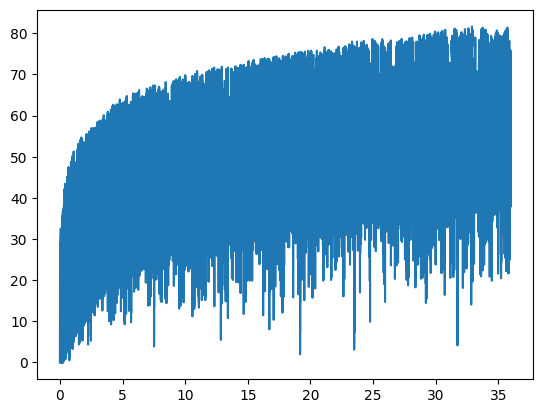

In [ ]:
from src.biases_trajectory import biases_trajectory


def extract_gaussians(p, num_steps, extract=True):
    sd = simulation_data(p)
    file = p.working_dir / "gaussians.npz"

    if extract:
        gs = None
        for step in range(num_steps):
            wd = simulation_data(p, subdir=step).working_dir
            gs_step = load_gaussians(wd / "deposited.npz")
            gs = gs + gs_step
        gs.save_npz(file)
        sd.save_and_assign_objects(dict(cvs=gs.centers))
    else:
        gs = load_gaussians(file)

    return sd, gs


def exact_num_gaussians_per_step(p, num_steps):
    num_gaussians = []
    for step in range(num_steps):
        wd = simulation_data(p, subdir=step).working_dir
        gs_step = load_gaussians(wd / "deposited.npz")
        num_gaussians.append(len(gs_step))
    return np.array(num_gaussians)


def ns_gaussians(p, num_gaussians):
    ns_per_gaussian = p.tau_G / unit.nanosecond

    total_gausians = np.sum(num_gaussians)
    return np.arange(total_gausians) * ns_per_gaussian


num_steps = step_start - 1
sd, gs = extract_gaussians(p, num_steps, extract=True)
num_gaussians = exact_num_gaussians_per_step(p, num_steps)
ns = ns_gaussians(p, num_gaussians)

calculate = False
if calculate:
    # biases = biases_trajectory(gs, dispatch='serial') # 20:24. 3e5 kernels
    biases = biases_trajectory(gs, dispatch="cupy")  #  0:37
    sd.save_and_assign_objects({"biases": biases})

plt.plot(ns, sd.biases)

### B. Maybe never?  `features`, `dihedrals`, `cvs` and other eigen data

In [ ]:
def extract_features_frames(num_steps):
    """THIS IS FOR THE FUTURE OR MAYBE NEVER

    TODO: Load in the SRV and transform the frames stored in the .h5 files:

        .h5 => features => cvs

    Also work out saving biases during simulation and associate these values with frames.
    """
    features = []
    dihedrals = []
    biases = []

    # collect simulation data
    for step in range(num_steps):
        sd = simulation_data(p, subdir=step, loud=False)
        features.append(sd.features)
        dihedrals.append(sd.dihedrals)
        biases.append(sd.biases)

    # save in main working directory
    sd = simulation_data(p)
    sd.save_and_assign_objects(
        dict(features=features, dihedrals=dihedrals, biases=biases)
    )